# Día 1

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

url = "https://raw.githubusercontent.com/datasets/gdp/master/data/gdp.csv"
df = pd.read_csv(url)

paises = ["Spain", "France", "Italy", "Germany"]

df = df[
    (df["Country Name"].isin(paises)) &
    (df["Year"].between(1960, 2026))
]

df

,Country Name,Country Code,Year,Value
4281,France,FRA,1960,6.222548e+10
4282,France,FRA,1961,6.746164e+10
4283,France,FRA,1962,7.560753e+10
4284,France,FRA,1963,8.475920e+10
4285,France,FRA,1964,9.400785e+10
...,...,...,...,...
11753,Spain,ESP,2019,1.394320e+12
11754,Spain,ESP,2020,1.278129e+12
11755,Spain,ESP,2021,1.445652e+12
11756,Spain,ESP,2022,1.417800e+12


# Día 2

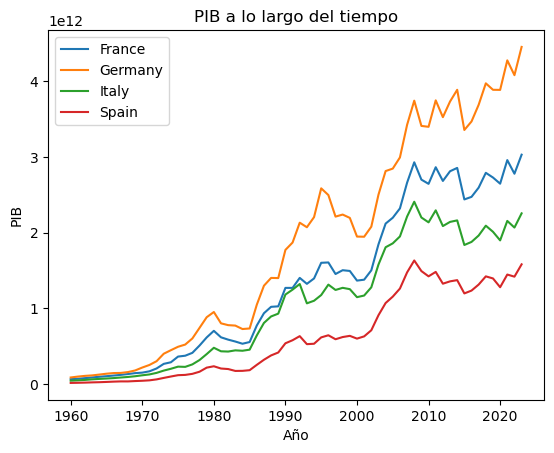

In [27]:
for pais in df["Country Name"].unique():
    subset = df[df["Country Name"] == pais]
    plt.plot(subset["Year"], subset["Value"], label=pais)

plt.title("PIB a lo largo del tiempo")
plt.xlabel("Año")
plt.ylabel("PIB")
plt.legend()
plt.show()

# Día 3

In [28]:
df["Growth"] = df.groupby("Country Name")["Value"].pct_change()

df

,Country Name,Country Code,Year,Value,Growth
4281,France,FRA,1960,6.222548e+10,NaN
4282,France,FRA,1961,6.746164e+10,0.084148
4283,France,FRA,1962,7.560753e+10,0.120748
4284,France,FRA,1963,8.475920e+10,0.121042
4285,France,FRA,1964,9.400785e+10,0.109117
...,...,...,...,...,...
11753,Spain,ESP,2019,1.394320e+12,-0.019260
11754,Spain,ESP,2020,1.278129e+12,-0.083332
11755,Spain,ESP,2021,1.445652e+12,0.131069
11756,Spain,ESP,2022,1.417800e+12,-0.019265


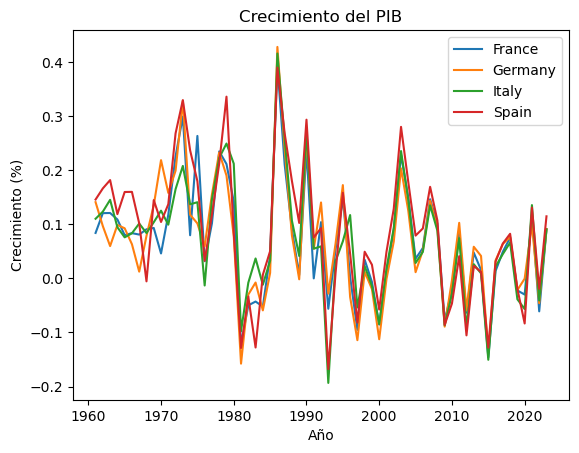

In [29]:
for pais in df["Country Name"].unique():
    subset = df[df["Country Name"] == pais]
    subset = subset.sort_values("Year")
    plt.plot(subset["Year"], subset["Growth"], label=pais)

plt.title("Crecimiento del PIB")
plt.xlabel("Año")
plt.ylabel("Crecimiento (%)")
plt.legend()
plt.show()

# Día 4

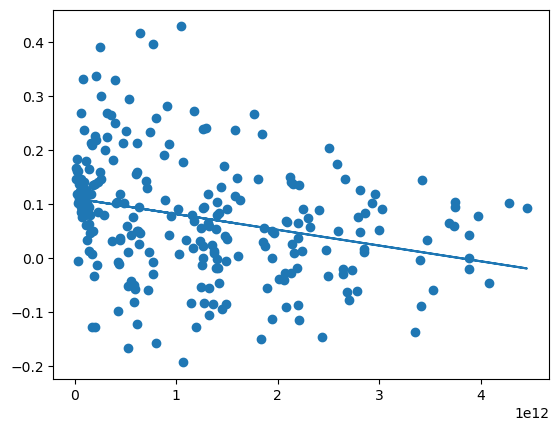

Pendiente: -2.911886213043268e-14
Correlación: -0.28617395746017155


In [30]:
df = df.dropna()

x = df["Value"]
y = df["Growth"]

m, b = np.polyfit(x, y, 1)

plt.scatter(x, y)
plt.plot(x, m*x + b)
plt.show()

print("Pendiente:", m)
print("Correlación:", x.corr(y))

# Día 5


In [31]:
nuevo_PIB = 30_000_000_000

prediccion = m * nuevo_PIB + b

print("Crecimiento estimado:", prediccion)

Crecimiento estimado: 0.10920170187110723


# Día 6

## Objetivo

### El objetivo de este estudio es analizar la relación entre el PIB y el crecimiento de varios países.

## Datos

### Los datos se han obtenido a partir de un dataset que recoje el crecimiento y el PIB de casi todos los países desde 1960 hasta 2023, lo que significa que la fuente no es escasa. Aunque en este estudio solo se han analizado 4 países (España, Francia, Italia, Alemania)

## Metodoligía

### Para poder relacionar el crecimiento con el PIB de estos países se ha creado un dataframe filtrado de ellos. A continuación se ha creado un gráfico para observar la evolución del PIB a lo largo del tiempo de los diferentes países estudiados. También se ha creado otro gráfico para relacionar el crecimiento en porcentaje del PIB a lo largo del tiempo de cada país. Por último, se ha hecho un gráfico de dispersión y se le ha aplicado una regresión lineal simple. También se ha predecido un posible crecimiento de estos países.

## Resultados

### Los resultados obtenidos en el estudio muestran que las economías de los países han crecido a lo largo del tiempo pudiendose observar en el primer gráfico el famoso "palo de hockey". El siguiente gráfico junto al gráfico de dispersión muestra que hay una relación negativa débil entre el PIB y el crecimiento de los países, esto se puede ver más claro gracias a la línea de regresión y al coeficiente de correlación.

## Conclusión

### Para concluir, en todos estos países con economías modernas se observa un patrón del PIB y una convergencia. En esta muestra aparece una relación negativa entre tamaño del PIB y crecimiento porcentual. Estas economías maduras han experimentado tasas de natalidad bajas en las últimas décadas a parte de la recesión del 2008 y la crisis del COVID. A una economía desarrollada le cuesta mucho más crecer que a una en desarrollo que suelen tener tasas bastantes altas al principio. Para resumir en las economías maduras, como las que se han analizado en este estudio, la producción total aumenta, pero a ritmos porcentuales menores.